# Lab 5 "Gradient analyze"

## Lab 5 short description

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import json
import os

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Data generation

In [3]:
def generate_binary_classification_data(n_samples=2000, n_features=20):
    """
    Генерирует линейно разделимый датасет для бинарной классификации.
    """
    # Класс 0
    X_class0 = np.random.randn(n_samples//2, n_features) + np.random.randn(n_samples//2, 1) * 0.5
    y_class0 = np.zeros(n_samples//2)
    
    # Класс 1 (смещён)
    X_class1 = np.random.randn(n_samples//2, n_features) + 2 + np.random.randn(n_samples//2, 1) * 0.5
    y_class1 = np.ones(n_samples//2)
    
    X = np.vstack([X_class0, X_class1]).astype(np.float32)
    y = np.hstack([y_class0, y_class1]).astype(np.float32)
    
    # Перемешивание
    indices = np.random.permutation(len(X))
    X, y = X[indices], y[indices]
    
    return X, y

In [4]:
xs, ys = generate_binary_classification_data(100, 2)

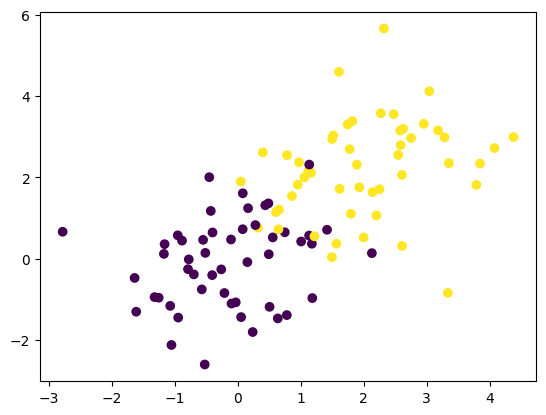

In [5]:
plt.scatter(xs[:,0], xs[:,1], c=ys)
plt.show()

## torch neural network

In [6]:
class SimpleNN(nn.Module):
    """Простая полносвязная нейронная сеть для классификации"""
    
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, output_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)
    
    def get_gradients(self):
        """Извлекает градиенты всех параметров модели"""
        gradients = []
        for param in self.parameters():
            if param.grad is not None:
                gradients.append(param.grad.detach().cpu().numpy().flatten())
        return np.concatenate(gradients) if gradients else np.array([])
    
    def get_gradient_norm(self):
        """Вычисляет L2-норму всех градиентов"""
        total_norm = 0
        for param in self.parameters():
            if param.grad is not None:
                param_norm = param.grad.detach().cpu().norm(2)
                total_norm += param_norm ** 2
        return total_norm ** 0.5

## Data poisoning attack

In [7]:
class DataPoisoningAttack:
    """Реализация атак отравления данных"""
    
    def __init__(self, X, y):
        self.X_clean = X.copy()
        self.y_clean = y.copy()
        self.X_poisoned = X.copy()
        self.y_poisoned = y.copy()
        self.poison_indices = []
    
    def label_flipping_attack(self, poison_ratio=0.2, seed=42):
        """
        Атака 1: Инверсия меток (Label Flipping)
        """
        np.random.seed(seed)
        n_samples = len(self.y_poisoned)
        n_poison = int(n_samples * poison_ratio)
        
        self.poison_indices = np.random.choice(n_samples, n_poison, replace=False)
        self.y_poisoned[self.poison_indices] = 1 - self.y_poisoned[self.poison_indices]
        
        print(f"Label Flipping: {n_poison} образцов ({poison_ratio*100:.1f}%)")
        return self.X_poisoned, self.y_poisoned
    
    def gradient_attack(self, poison_ratio=0.15, magnitude=5.0, seed=42):
        """
        Атака 2: Целевое воздействие на градиенты
        Добавляем выбросы в признаки для создания аномальных градиентов
        """
        np.random.seed(seed)
        n_samples = len(self.y_poisoned)
        n_poison = int(n_samples * poison_ratio)
        
        # Выбираем образцы из класса 0 для атаки
        class0_indices = np.where(self.y_poisoned == 0)[0]
        self.poison_indices = np.random.choice(class0_indices, n_poison, replace=False)
        
        # Добавляем сильные выбросы в признаки
        self.X_poisoned[self.poison_indices] += np.random.randn(n_poison, self.X_poisoned.shape[1]) * magnitude
        
        # Меняем метки на противоположные
        self.y_poisoned[self.poison_indices] = 1 - self.y_poisoned[self.poison_indices]
        
        print(f"Gradient Attack: {n_poison} образцов, magnitude={magnitude}")
        return self.X_poisoned, self.y_poisoned
    
    def get_poison_mask(self):
        """Возвращает маску отравленных образцов"""
        mask = np.zeros(len(self.y_clean), dtype=bool)
        mask[self.poison_indices] = True
        return mask

## Gradient analyze

In [8]:
class GradientAnalyzer:
    """Анализатор градиентов для обнаружения аномалий"""
    
    def __init__(self):
        self.gradient_norms = []
        self.gradient_samples = []
        self.batch_losses = []
        self.sample_gradients = []  # Градиенты для каждого образца
        self.sample_indices = []
    
    def record_batch_gradient(self, model, batch_loss, batch_indices):
        """Записывает статистику градиентов для батча"""
        grad_norm = model.get_gradient_norm()
        self.gradient_norms.append(grad_norm)
        self.batch_losses.append(batch_loss)
        
        # Сохраняем полные градиенты для анализа
        self.gradient_samples.append(model.get_gradients())
        self.sample_indices.extend(batch_indices)
    
    def record_sample_gradient(self, gradient_vector, sample_idx):
        """Записывает градиент для отдельного образца"""
        self.sample_gradients.append(gradient_vector)
    
    def compute_gradient_statistics(self):
        """Вычисляет статистику по всем градиентам"""
        if not self.gradient_norms:
            return {}
        
        norms = np.array(self.gradient_norms)
        return {
            'mean_norm': float(np.mean(norms)),
            'std_norm': float(np.std(norms)),
            'max_norm': float(np.max(norms)),
            'min_norm': float(np.min(norms)),
            'median_norm': float(np.median(norms)),
            'q75': float(np.percentile(norms, 75)),
            'q25': float(np.percentile(norms, 25)),
            'iqr': float(np.percentile(norms, 75) - np.percentile(norms, 25))
        }


    def detect_anomalies_iqr(self, threshold_multiplier=1.5):
        """
        Обнаружение аномалий методом IQR (Interquartile Range)
        """
        norms = np.array(self.gradient_norms)
        q1 = np.percentile(norms, 25)
        q3 = np.percentile(norms, 75)
        iqr = q3 - q1
        
        lower_bound = q1 - threshold_multiplier * iqr
        upper_bound = q3 + threshold_multiplier * iqr
        
        anomalies = (norms < lower_bound) | (norms > upper_bound)
        anomaly_indices = np.where(anomalies)[0]
        
        return {
            'anomaly_count': int(np.sum(anomalies)),
            'anomaly_ratio': float(np.mean(anomalies)),
            'anomaly_indices': anomaly_indices.tolist(),
            'thresholds': {'lower': lower_bound, 'upper': upper_bound}
        }
    
    def detect_anomalies_zscore(self, threshold=3.0):
        """
        Обнаружение аномалий методом Z-Score
        """
        norms = np.array(self.gradient_norms)
        mean = np.mean(norms)
        std = np.std(norms)
        
        if std == 0:
            return {'anomaly_count': 0, 'anomaly_ratio': 0.0, 'anomaly_indices': []}
        
        z_scores = np.abs((norms - mean) / std)
        anomalies = z_scores > threshold
        anomaly_indices = np.where(anomalies)[0]
        
        return {
            'anomaly_count': int(np.sum(anomalies)),
            'anomaly_ratio': float(np.mean(anomalies)),
            'anomaly_indices': anomaly_indices.tolist(),
            'z_scores': z_scores.tolist()
        }
         

## ML learning with gradient monitoring 

In [9]:
def train_with_gradient_monitoring(
    model, 
    X_train, 
    y_train, 
    X_test, 
    y_test,
    epochs=20, 
    batch_size=32, 
    learning_rate=0.01,
    track_per_sample=False
):
    """
    Обучение модели с подробным мониторингом градиентов
    """
    dataset = TensorDataset(
        torch.tensor(X_train), 
        torch.tensor(y_train).unsqueeze(1)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    analyzer = GradientAnalyzer()
    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': [],
        'gradient_norms': []
    }
    
    print("\n" + "="*70)
    print("НАЧАЛО ОБУЧЕНИЯ С МОНИТОРИНГОМ ГРАДИЕНТОВ")
    print("="*70)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_gradients = []
        
        for batch_idx, (X_batch, y_batch) in enumerate(loader):
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            loss.backward()
            
            # Запись градиентов
            batch_indices = list(range(batch_idx * batch_size, 
                                      min((batch_idx + 1) * batch_size, len(X_train))))
            analyzer.record_batch_gradient(model, loss.item(), batch_indices)
            epoch_gradients.append(model.get_gradient_norm())
            
            # Обновление весов
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Оценка на тесте
        model.eval()
        with torch.no_grad():
            train_pred = (model(torch.tensor(X_train)) > 0.5).float()
            test_pred = (model(torch.tensor(X_test)) > 0.5).float()
            
            train_acc = accuracy_score(y_train, train_pred.numpy())
            test_acc = accuracy_score(y_test, test_pred.numpy())
            
            test_loss = criterion(
                model(torch.tensor(X_test)), 
                torch.tensor(y_test).unsqueeze(1)
            ).item()
                # Запись истории
        history['train_loss'].append(epoch_loss / len(loader))
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['gradient_norms'].append(np.mean(epoch_gradients))
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Test Acc: {test_acc:.4f} | "
                  f"Grad Norm: {history['gradient_norms'][-1]:.4f}")
    
    print("="*70)
    
    return model, history, analyzer

## Visualization

In [10]:
class GradientVisualizer:
    """Визуализация результатов анализа градиентов"""
    
    def __init__(self, save_dir="results"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    
    def plot_gradient_norms(self, analyzer, poison_mask=None, title="Gradient Norms"):
        """График норм градиентов по батчам"""
        plt.figure(figsize=(14, 6))
        
        norms = np.array(analyzer.gradient_norms)
        epochs = range(len(norms))
        
        plt.plot(epochs, norms, 'b-o', label='Gradient Norm', alpha=0.7)
        plt.axhline(y=np.mean(norms), color='g', linestyle='--', label=f'Mean: {np.mean(norms):.4f}')
        plt.axhline(y=np.mean(norms) + 2*np.std(norms), color='r', linestyle='--', 
                   label=f'Mean + 2σ: {np.mean(norms) + 2*np.std(norms):.4f}')
        plt.axhline(y=np.mean(norms) - 2*np.std(norms), color='r', linestyle='--',
                   label=f'Mean - 2σ: {np.mean(norms) - 2*np.std(norms):.4f}')
        
        plt.xlabel('Batch / Epoch')
        plt.ylabel('Gradient L2 Norm')
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.savefig(f"{self.save_dir}/gradient_norms.png", dpi=300)
        plt.close()
        print(f"Сохранено: {self.save_dir}/gradient_norms.png")


    def plot_gradient_distribution(self, analyzer, title="Gradient Norm Distribution"):
        """Гистограмма распределения норм градиентов"""
        plt.figure(figsize=(12, 6))
        
        norms = np.array(analyzer.gradient_norms)
        
        plt.subplot(1, 2, 1)
        plt.hist(norms, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        plt.xlabel('Gradient Norm')
        plt.ylabel('Frequency')
        plt.title(f'{title}\nMean={np.mean(norms):.4f}, Std={np.std(norms):.4f}')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        sns.boxplot(data=norms)
        plt.ylabel('Gradient Norm')
        plt.title('Box Plot (выбросы помечены точками)')
        
        plt.tight_layout()
        plt.savefig(f"{self.save_dir}/gradient_distribution.png", dpi=300)
        plt.close()
        print(f"Сохранено: {self.save_dir}/gradient_distribution.png")
    
    def plot_training_history(self, history, title="Training History"):
        """График истории обучения"""
        plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['test_loss'], label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{title} - Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(history['train_acc'], label='Train Accuracy')
        plt.plot(history['test_acc'], label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'{title} - Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f"{self.save_dir}/training_history.png", dpi=300)
        plt.close()
        print(f"Сохранено: {self.save_dir}/training_history.png")

    def plot_anomaly_detection(self, analyzer, detection_results, title="Anomaly Detection"):
        """Визуализация обнаруженных аномалий"""
        plt.figure(figsize=(14, 6))
        
        norms = np.array(analyzer.gradient_norms)
        epochs = range(len(norms))
        
        plt.scatter(epochs, norms, alpha=0.5, label='Normal', color='blue')
        
        if detection_results['anomaly_indices']:
            anomaly_epochs = detection_results['anomaly_indices']
            anomaly_norms = norms[anomaly_epochs]
            plt.scatter(anomaly_epochs, anomaly_norms, alpha=0.8, 
                       label=f'Anomalies ({detection_results["anomaly_count"]})', 
                       color='red', s=100, marker='x')
        
        plt.axhline(y=detection_results['thresholds']['upper'], color='r', 
                   linestyle='--', label='Upper Threshold')
        plt.axhline(y=detection_results['thresholds']['lower'], color='r', 
                   linestyle='--', label='Lower Threshold')
        
        plt.xlabel('Batch / Epoch')
        plt.ylabel('Gradient Norm')
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.savefig(f"{self.save_dir}/anomaly_detection.png", dpi=300)
        plt.close()
        print(f"Сохранено: {self.save_dir}/anomaly_detection.png")

## Main scenario

In [11]:
def run_lab_scenario():
    """Основной сценарий лабораторной работы"""
    
    print("\n" + "="*70)
    print("ЛАБОРАТОРНАЯ РАБОТА: АНАЛИЗ АНОМАЛИЙ В ГРАДИЕНТАХ")
    print("MITRE ATLAS TML0010: Data Poisoning")
    print("="*70)
    
    # Параметры
    N_SAMPLES = 2000
    N_FEATURES = 20
    TEST_SIZE = 0.2
    EPOCHS = 20
    BATCH_SIZE = 32
    LEARNING_RATE = 0.01
    POISON_RATIOS = [0.0, 0.1, 0.2, 0.3]  # 0% = чистые данные
    
    results_summary = []
    visualizer = GradientVisualizer(save_dir="results")

    # =========================================================
    # Сценарий 1: Обучение на чистых данных (Baseline)
    # =========================================================
    print("\n" + "="*70)
    print("СЦЕНАРИЙ 1: ЧИСТЫЕ ДАННЫЕ (BASELINE)")
    print("="*70)
    
    X, y = generate_binary_classification_data(N_SAMPLES, N_FEATURES)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )
    
    model_clean = SimpleNN(input_dim=N_FEATURES)
    model_clean, history_clean, analyzer_clean = train_with_gradient_monitoring(
        model_clean, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE
    )
    
    # Анализ градиентов
    stats_clean = analyzer_clean.compute_gradient_statistics()
    anomalies_clean = analyzer_clean.detect_anomalies_iqr()
    
    visualizer.plot_gradient_norms(analyzer_clean, title="Clean Data - Gradient Norms")
    visualizer.plot_gradient_distribution(analyzer_clean, title="Clean Data - Distribution")
    visualizer.plot_training_history(history_clean, title="Clean Data")
    visualizer.plot_anomaly_detection(analyzer_clean, anomalies_clean, title="Clean Data - Anomaly Detection")
    
    results_summary.append({
        'scenario': 'clean',
        'poison_ratio': 0.0,
        'test_accuracy': float(history_clean['test_acc'][-1]),
        'mean_gradient_norm': stats_clean['mean_norm'],
        'std_gradient_norm': stats_clean['std_norm'],
        'anomaly_ratio': anomalies_clean['anomaly_ratio']
    })


    # Генерация новых данных для каждого сценария
    X, y = generate_binary_classification_data(N_SAMPLES, N_FEATURES)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )
    
    # Атака
    poison_ratio = POISON_RATIOS[2]
    attack = DataPoisoningAttack(X_train, y_train)
    X_train_poisoned, y_train_poisoned = attack.label_flipping_attack(
        poison_ratio=poison_ratio
    )
    
    # Обучение
    model_poisoned = SimpleNN(input_dim=N_FEATURES)
    model_poisoned, history_poisoned, analyzer_poisoned = train_with_gradient_monitoring(
        model_poisoned, X_train_poisoned, y_train_poisoned, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE
    )
    
    # Анализ
    stats_poisoned = analyzer_poisoned.compute_gradient_statistics()
    anomalies_poisoned = analyzer_poisoned.detect_anomalies_iqr()
    
    # Визуализация
    visualizer.plot_gradient_norms(
        analyzer_poisoned, 
        title=f"Poisoned {poison_ratio*100:.0f}% - Gradient Norms"
    )
    visualizer.plot_gradient_distribution(
        analyzer_poisoned, 
        title=f"Poisoned {poison_ratio*100:.0f}% - Distribution"
    )
    visualizer.plot_training_history(
        history_poisoned, 
        title=f"Poisoned {poison_ratio*100:.0f}%"
    )
    visualizer.plot_anomaly_detection(
        analyzer_poisoned, 
        anomalies_poisoned, 
        title=f"Poisoned {poison_ratio*100:.0f}% - Anomaly Detection"
    )
    
    results_summary.append({
        'scenario': f'poisoned_{int(poison_ratio*100)}',
        'poison_ratio': poison_ratio,
        'test_accuracy': float(history_poisoned['test_acc'][-1]),
        'mean_gradient_norm': stats_poisoned['mean_norm'],
        'std_gradient_norm': stats_poisoned['std_norm'],
        'anomaly_ratio': anomalies_poisoned['anomaly_ratio']})


    # =========================================================
    # Сводные результаты
    # =========================================================
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("="*70)
    
    df_results = pd.DataFrame(results_summary)
    print(df_results.to_string(index=False))
    
    # Сохранение результатов
    with open("results/summary.json", "w") as f:
        json.dump(results_summary, f, indent=2)
    
    df_results.to_csv("results/summary.csv", index=False)
    print(f"\nРезультаты сохранены в results/summary.json и results/summary.csv")
    
    # =========================================================
    # Сравнительная визуализация
    # =========================================================
    plt.figure(figsize=(12, 6))
    plt.plot(df_results['poison_ratio'], df_results['test_accuracy'], 
             'o-', label='Test Accuracy', linewidth=2)
    plt.plot(df_results['poison_ratio'], df_results['anomaly_ratio'], 
             's--', label='Anomaly Ratio', linewidth=2)
    plt.xlabel('Poison Ratio')
    plt.ylabel('Value')
    plt.title('Impact of Data Poisoning on Model and Gradient Anomalies')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("results/impact_comparison.png", dpi=300)
    plt.close()
    print("Сохранено: results/impact_comparison.png")
    
    return df_results                
    

In [12]:
 run_lab_scenario()


ЛАБОРАТОРНАЯ РАБОТА: АНАЛИЗ АНОМАЛИЙ В ГРАДИЕНТАХ
MITRE ATLAS TML0010: Data Poisoning

СЦЕНАРИЙ 1: ЧИСТЫЕ ДАННЫЕ (BASELINE)

НАЧАЛО ОБУЧЕНИЯ С МОНИТОРИНГОМ ГРАДИЕНТОВ
Epoch  1/20 | Train Loss: 0.1747 | Test Acc: 0.9550 | Grad Norm: 0.5870
Epoch  5/20 | Train Loss: 0.0795 | Test Acc: 0.9625 | Grad Norm: 0.3328
Epoch 10/20 | Train Loss: 0.0583 | Test Acc: 0.9600 | Grad Norm: 0.2942
Epoch 15/20 | Train Loss: 0.0552 | Test Acc: 0.9600 | Grad Norm: 0.2965
Epoch 20/20 | Train Loss: 0.0577 | Test Acc: 0.9650 | Grad Norm: 0.3048
Сохранено: results/gradient_norms.png
Сохранено: results/gradient_distribution.png
Сохранено: results/training_history.png
Сохранено: results/anomaly_detection.png
Label Flipping: 320 образцов (20.0%)

НАЧАЛО ОБУЧЕНИЯ С МОНИТОРИНГОМ ГРАДИЕНТОВ
Epoch  1/20 | Train Loss: 0.5878 | Test Acc: 0.9625 | Grad Norm: 0.5403
Epoch  5/20 | Train Loss: 0.5275 | Test Acc: 0.9475 | Grad Norm: 0.4294
Epoch 10/20 | Train Loss: 0.5018 | Test Acc: 0.9350 | Grad Norm: 0.5114
Epoch 15/20 

,scenario,poison_ratio,test_accuracy,mean_gradient_norm,std_gradient_norm,anomaly_ratio
0,clean,0.0,0.965,0.331951,0.252124,0.036
1,poisoned_20,0.2,0.925,0.499486,0.193348,0.039
